 # Drug Target Binding Affinity Prediction



 **Project:** Prediction of Drug-Target Binding Affinity Using Protein and Ligand Features

 **Dataset:** BindingDB High Confidence pKd Clean

 **Authors:** Islam Dyussenov, Adil Utepov



 This notebook provides an end-to-end ML pipeline:



 1. Load BindingDB dataset

 2. Exploratory Data Analysis

 3. Feature Engineering

 4. Baseline Models

 5. Deep Learning Model

 6. Evaluation

 7. Inference



In [ ]:
#Install dependencies (run in Colab if needed)
#!pip install rdkit-pypi xgboost tensorflow scikit-learn seaborn



In [ ]:
import sys
print(sys.executable)


c:\Users\Admin\AppData\Local\Programs\Python\Python313\python.exe


In [1]:
from rdkit import Chem
import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb   
import torch 
import numpy as np

print("Все библиотеки работают")


Все библиотеки работают


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor



 ## Load Dataset

In [ ]:
# Put CSV in same folder or Colab files
PATH = r"bindingdb_highconf_pKd_clean.csv"

df = pd.read_csv(PATH)
print(df.shape)
df.head()



(2081891, 3)


,compound_iso_smiles,target_sequence,affinity
0,O[C@@H]1[C@@H](O)[C@@H](Cc2ccccc2)N(CCCCCC(O)=...,PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...,9.619789
1,O[C@@H]1[C@@H](O)[C@@H](Cc2ccccc2)N(C\C=C\c2cn...,PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...,9.602060
2,O[C@@H]1[C@@H](O)[C@@H](Cc2ccccc2)N(CC2CC2)C(=...,PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...,9.387216
3,OCCCCCCN1[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)[C@@...,PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...,9.096910
4,OCCCCCN1[C@H](Cc2ccccc2)[C@H](O)[C@@H](O)[C@@H...,PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMSLPGRWKPKM...,9.004365


 ## Optional Sampling (recommended for faster training)

In [ ]:
df = df.sample(min(len(df), 100000), random_state=42).reset_index(drop=True)
print(df.shape)



(100000, 3)


 ## Basic EDA

Unique compounds: 92825
Unique proteins: 4799


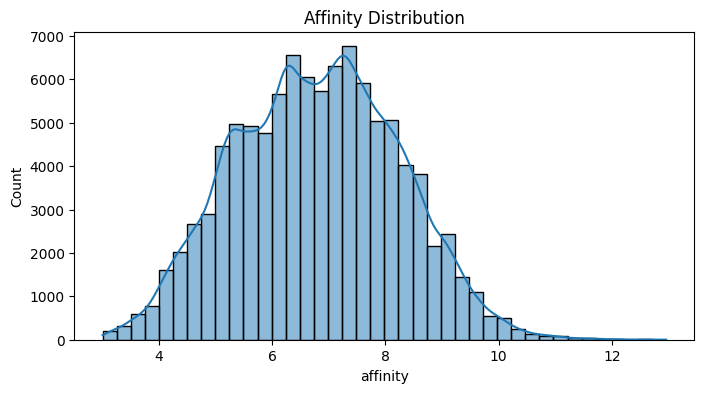

In [ ]:
print('Unique compounds:', df['compound_iso_smiles'].nunique())
print('Unique proteins:', df['target_sequence'].nunique())

plt.figure(figsize=(8,4))
sns.histplot(df['affinity'], bins=40, kde=True)
plt.title('Affinity Distribution')
plt.show()



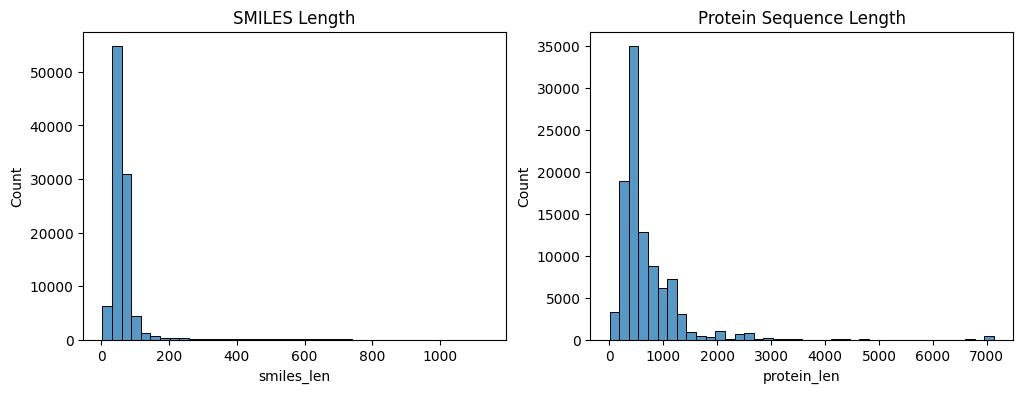

In [ ]:
df['smiles_len'] = df['compound_iso_smiles'].str.len()
df['protein_len'] = df['target_sequence'].str.len()

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['smiles_len'], bins=40, ax=ax[0])
ax[0].set_title('SMILES Length')

sns.histplot(df['protein_len'], bins=40, ax=ax[1])
ax[1].set_title('Protein Sequence Length')
plt.show()



 ## Feature Engineering

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df[['compound_iso_smiles', 'target_sequence']],
    df['affinity'],
    test_size=0.2,
    random_state=42
)

In [ ]:
# Lightweight text features for demo pipeline
#TRAIN
smiles_vec = CountVectorizer(analyzer='char', ngram_range=(1,3), max_features=500)
protein_vec = CountVectorizer(analyzer='char', ngram_range=(1,3), max_features=500)

X_smiles_train = smiles_vec.fit_transform(X_train_raw['compound_iso_smiles'])
X_prot_train = protein_vec.fit_transform(X_train_raw['target_sequence'])





In [ ]:
#TEST
X_smiles_test = smiles_vec.transform(X_test_raw['compound_iso_smiles'])
X_prot_test = protein_vec.transform(X_test_raw['target_sequence'])

In [ ]:
#Final Dataset Construction
from scipy.sparse import hstack

X_train = hstack([X_smiles_train, X_prot_train])
X_test = hstack([X_smiles_test, X_prot_test])

 ## Baseline Model: Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train[:20000].toarray(), y_train[:20000])

pred_rf = rf.predict(X_test[:5000].toarray())

rmse_rf = np.sqrt(mean_squared_error(y_test[:5000], pred_rf))
mae_rf = mean_absolute_error(y_test[:5000], pred_rf)
r2_rf = r2_score(y_test[:5000], pred_rf)

print('RF RMSE:', rmse_rf)
print('RF MAE:', mae_rf)
print('RF R2:', r2_rf)

RF RMSE: 1.1877442381823418
RF MAE: 0.9415735031952827
RF R2: 0.3192771991881016


 ## MLflow helper

In [ ]:
import mlflow
import joblib

def log_model_mlflow(model, model_name, metrics, file_name):
    """
    Logs model + metrics to MLflow in a unified way
    """

    with mlflow.start_run():

        # --- model metadata ---
        mlflow.log_param("model", model_name)

        # --- metrics ---
        mlflow.log_metric("rmse", metrics.get("rmse"))
        mlflow.log_metric("mae", metrics.get("mae"))
        mlflow.log_metric("r2", metrics.get("r2"))

        # --- save model artifact ---
        if file_name.endswith(".keras"):
            model.save(file_name)
        else:
            joblib.dump(model, file_name)

        # --- log artifact ---
        mlflow.log_artifact(file_name)

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
log_model_mlflow(
    model=rf,
    model_name="RandomForest",
    metrics={
        "rmse": rmse_rf,
        "mae": mae_rf,
        "r2": r2_rf
    },
    file_name="rf_model.joblib"
)

2026/05/13 23:49:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/13 23:49:29 INFO mlflow.store.db.utils: Updating database tables


 ## Gradient Boosting: XGBoost

In [ ]:
import sys
print(sys.executable)


c:\Users\Admin\AppData\Local\Programs\Python\Python310\python.exe


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
print("OK")


OK


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae_xgb = mean_absolute_error(y_test, pred_xgb)
r2_xgb = r2_score(y_test, pred_xgb)

print('XGB RMSE:', rmse_xgb)
print('XGB MAE:', mae_xgb)
print('XGB R2:', r2_xgb)

XGB RMSE: 1.0918261291059792
XGB MAE: 0.8671356493205001
XGB R2: 0.42262921090516437


In [ ]:
log_model_mlflow(
    model=xgb,
    model_name="XGBoost",
    metrics={
        "rmse": rmse_xgb,
        "mae": mae_xgb,
        "r2": r2_xgb
    },
    file_name="xgb_model.joblib"
)

 ## Deep Learning Model (TensorFlow)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

X_train_dense = X_train[:50000].toarray()
X_test_dense = X_test[:10000].toarray()

y_train_small = y_train[:50000]
y_test_small = y_test[:10000]

model = models.Sequential([
    layers.Input(shape=(X_train_dense.shape[1],)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train_dense,
    y_train_small,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    verbose=1
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 13.2255 - mae: 2.1131 - val_loss: 3.1478 - val_mae: 1.3813
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4534 - mae: 1.4426 - val_loss: 2.5114 - val_mae: 1.2424
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.8444 - mae: 1.3188 - val_loss: 2.4825 - val_mae: 1.2483
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5325 - mae: 1.2506 - val_loss: 2.2017 - val_mae: 1.1713
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2245 - mae: 1.1757 - val_loss: 1.9599 - val_mae: 1.1071
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.0823 - mae: 1.1398 - val_loss: 2.0669 - val_mae: 1.1410
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.9723 - mae: 1.1137 - val_loss: 1.8051 - val_mae: 1.0687
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8756 - mae: 1.0841 - val_loss: 2.1771 - val_mae: 1.1726
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - l

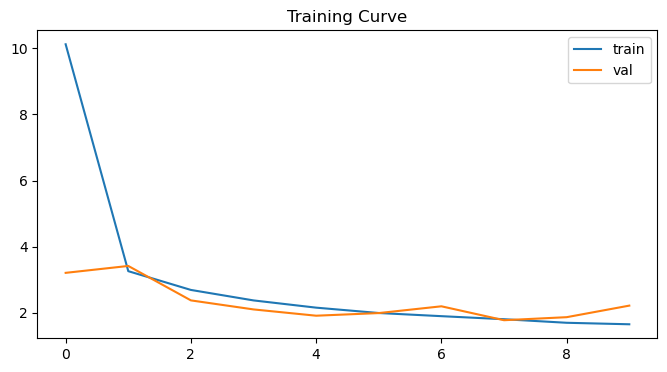

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Training Curve')
plt.legend()
plt.show()



In [ ]:
pred_dl = model.predict(X_test_dense).flatten()

rmse_dl = np.sqrt(mean_squared_error(y_test_small, pred_dl))
mae_dl = mean_absolute_error(y_test_small, pred_dl)
r2_dl = r2_score(y_test_small, pred_dl)

print('DL RMSE:', rmse_dl)
print('DL MAE:', mae_dl)
print('DL R2:', r2_dl)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
DL RMSE: 1.3118606840009757
DL MAE: 1.0431294450568172
DL R2: 0.160099799781655


In [ ]:
log_model_mlflow(
    model=model,
    model_name="DeepLearning",
    metrics={
        "rmse": rmse_dl,
        "mae": mae_dl,
        "r2": r2_dl
    },
    file_name="dl_model.keras"
)

 ## Predicted vs Actual

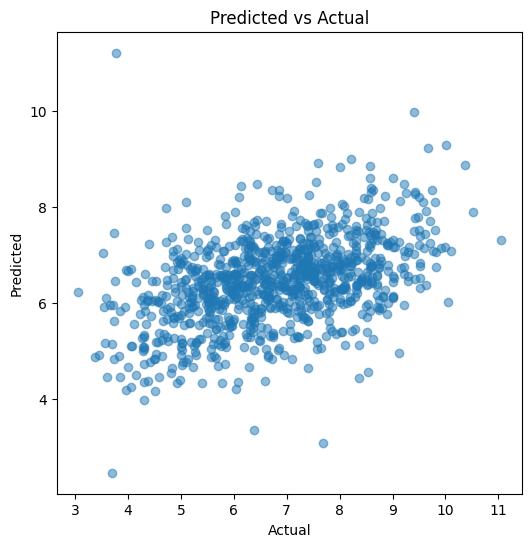

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_small[:1000], pred_dl[:1000], alpha=0.5)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show()



 ## Inference Example

In [ ]:
def predict_affinity(smiles, protein):
    xs = smiles_vec.transform([smiles])
    xp = protein_vec.transform([protein])
    xx = hstack([xs, xp]).toarray()
    return float(model.predict(xx, verbose=0)[0][0])

sample_smiles = 'CCO'
sample_protein = 'MKTLLILAVVAFAS'
print('Predicted affinity:', predict_affinity(sample_smiles, sample_protein))



Predicted affinity: 3.3493244647979736


## GNN TRAINING PIPELINE (PyTorch Geometric)

In [ ]:
import torch 
import numpy as np


AttributeError: partially initialized module 'torch' has no attribute 'version' (most likely due to a circular import)

In [2]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import pandas as pd

from gnn_dataset import DrugDataset
from gnn_model import GCN

print('Импортируем библиотеки и загружаем небольшую часть датасета...')
df = pd.read_csv('bindingdb_highconf_pKd_clean.csv', nrows=20000)
print('Готово!')

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Импортируем библиотеки и загружаем небольшую часть датасета...
Готово!


In [3]:
dataset = DrugDataset(df)

In [4]:
# TRAIN / TEST SPLIT
train_idx, test_idx = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    random_state=42
)

train_dataset = [dataset[i] for i in train_idx]
test_dataset = [dataset[i] for i in test_idx]

In [5]:
# DATALOADER
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [6]:
# MODEL + OPTIMIZER
from gnn_model import GCN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()

print(f'Модель GCN загружена на {device}')

Модель GCN загружена на cuda


In [7]:
gnn_train_losses = []
# TRAIN LOOP
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        out = model(batch.x, batch.edge_index, batch.batch)

        loss = loss_fn(out.view(-1), batch.y.view(-1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    gnn_train_losses.append(avg_loss)
    print(f'Epoch {epoch+1} | Loss: {avg_loss:.4f}')


torch.save(model.state_dict(), 'gnn_model.pth')
print('Модель GNN успешно сохранена!')

Epoch 1 | Loss: 3.7030
Epoch 2 | Loss: 2.0979
Epoch 3 | Loss: 2.0879
Epoch 4 | Loss: 2.0742
Epoch 5 | Loss: 2.0885
Epoch 6 | Loss: 2.0651
Epoch 7 | Loss: 2.0785
Epoch 8 | Loss: 2.0734
Epoch 9 | Loss: 2.0599
Epoch 10 | Loss: 2.0650
Модель GNN успешно сохранена!


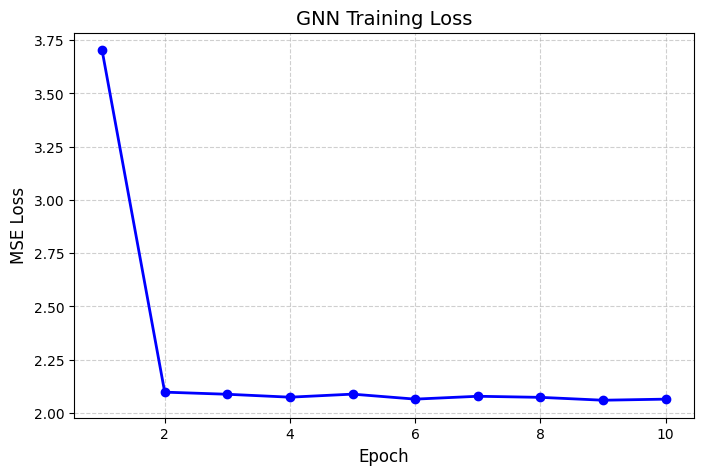

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gnn_train_losses) + 1), gnn_train_losses, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('GNN Training Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
# EVAL LOOP
model.eval()

preds = []
targets = []

with torch.no_grad():
    for batch in test_loader:

        batch = batch.to(device)

        out = model(batch.x, batch.edge_index, batch.batch)

        preds.append(out.cpu())
        targets.append(batch.y.cpu())

preds = torch.cat(preds).view(-1)
targets = torch.cat(targets).view(-1)

In [10]:
# metrics 
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(targets, preds))
r2 = r2_score(targets, preds)

print("GNN RMSE:", rmse)
print("GNN R2:", r2)

GNN RMSE: 1.4297230200185445
GNN R2: 0.03286921977996826


## DUAL ENCODER TRAINING (GNN + Protein Transformer)

In [11]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import pandas as pd

from gnn_dataset import DrugDataset
from gnn_model import GCN

print('Импортируем библиотеки и загружаем небольшую часть датасета...')
df = pd.read_csv('bindingdb_highconf_pKd_clean.csv', nrows=20000)
print('Готово!')

Импортируем библиотеки и загружаем небольшую часть датасета...
Готово!


In [12]:
dataset = DrugDataset(df)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)


In [14]:
# MODEL INIT
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from protein_transformer import ProteinTransformer, encode_protein

class GCNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(5, 64)
        self.conv2 = GCNConv(64, 128)
    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return global_mean_pool(x, batch) # [B, 128]

drug_model = GCNEncoder()
protein_model = ProteinTransformer()

class DualModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.drug = drug_model
        self.protein = protein_model

        # 🔥 ATTENTION FUSION
        self.attn = nn.MultiheadAttention(
            embed_dim=128,
            num_heads=4,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, drug_data, protein_emb):

        # --- drug embedding ---
        drug_emb = self.drug(
            drug_data.x,
            drug_data.edge_index,
            drug_data.batch
        )

        # --- protein embedding ---
        protein_emb = self.protein(protein_emb) # 🔥 ACTUALLY PROCESS THE PROTEIN THROUGH TRANSFORMER
        # protein_emb shape: [B, 128]

        # 🔥 reshape for attention
        drug_emb = drug_emb.unsqueeze(1)       # [B, 1, 128]
        protein_emb = protein_emb.unsqueeze(1) # [B, 1, 128]

        # 🔥 attention between drug and protein
        attn_out, _ = self.attn(
            query=drug_emb,
            key=protein_emb,
            value=protein_emb
        )

        # remove sequence dimension
        fused = attn_out.squeeze(1)  # [B, 128]

        return self.fc(fused)

model = DualModel().to(device)

In [15]:
# LOSS + OPTIMIZER
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [16]:
protein_cache = {}

In [17]:
def get_protein_embedding(seq):

    if seq in protein_cache:
        return protein_cache[seq]

    emb = encode_protein(seq).long().to(device)

    protein_cache[seq] = emb
    return emb

In [18]:
print("Precomputing protein embeddings...")

for i in range(len(df)):
    seq = df.iloc[i]["target_sequence"]
    protein_cache[seq] = encode_protein(seq).long().to(device)

print("Done caching proteins")

Precomputing protein embeddings...
Done caching proteins


In [19]:
dual_train_losses = []
# TRAIN LOOP
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        # 🔥 batch = list[Data]
        proteins = batch.protein

        # 🔥 STEP 8: use cache (FAST)
        protein_emb = torch.stack([
            get_protein_embedding(seq) for seq in proteins
        ]).to(device)

        # move graph batch to device
        batch = batch.to(device)

        # forward pass
        out = model(batch, protein_emb)

        # labels
        y = batch.y.view(-1).to(device)

        loss = loss_fn(out.view(-1), y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    dual_train_losses.append(avg_loss)
    print(f'Epoch {epoch+1} | Loss: {avg_loss:.4f}')


torch.save(model.state_dict(), 'gnn_model.pth')
print('Модель GNN успешно сохранена!')

Epoch 1 | Loss: 2.3529
Epoch 2 | Loss: 2.1171
Epoch 3 | Loss: 2.0992
Epoch 4 | Loss: 2.0665
Epoch 5 | Loss: 2.0766
Epoch 6 | Loss: 2.0465
Epoch 7 | Loss: 2.0604
Epoch 8 | Loss: 2.0633
Epoch 9 | Loss: 2.0497
Epoch 10 | Loss: 2.0520
Модель GNN успешно сохранена!


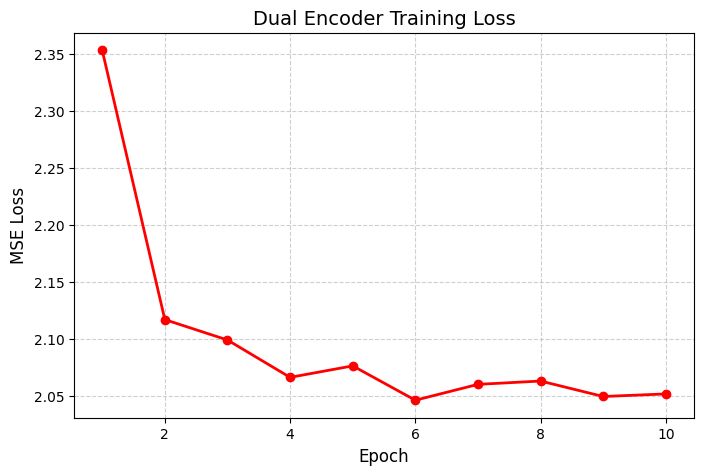

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(dual_train_losses) + 1), dual_train_losses, marker='o', linestyle='-', color='r', linewidth=2)
plt.title('Dual Encoder Training Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

🔹 1. Drug branch

SMILES → graph → GNN → embedding

🔹 2. Protein branch

Sequence → tokens → transformer → embedding

🔹 3. Fusion

Attention learns interaction between both embeddings

🔹 4. Output

MLP predicts binding affinity

 ## Final Notes



 For higher accuracy upgrade pipeline to:



 - RDKit Morgan Fingerprints

 - ProtBERT / ESM Protein Embeddings

 - Dual Branch Neural Network

 - Hyperparameter Tuning

 - FastAPI Deployment

